Sweep sizes : [2048, 4096]
Benchmarks  : ['401.bzip2', '429.mcf', '456.hmmer', '458.sjeng', '470.lbm']
Metrics     : ['cpi', 'btb_miss_pct', 'branch_pred_miss_pct']



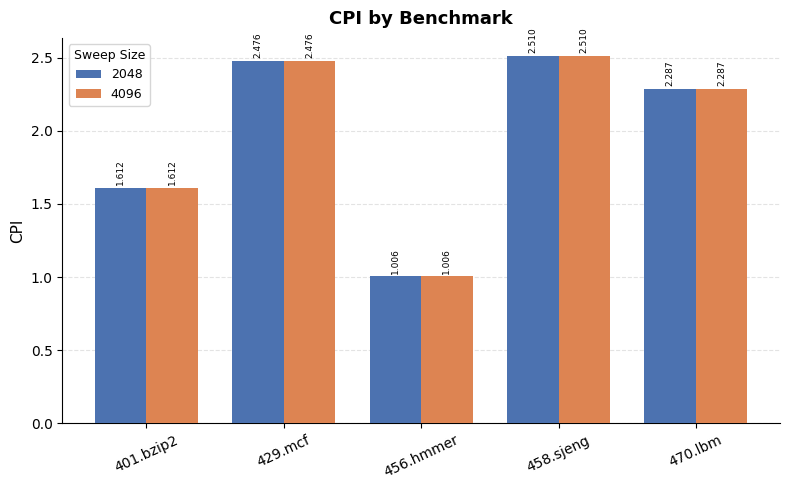

  Saved → globalSweep_cpi_bar.png


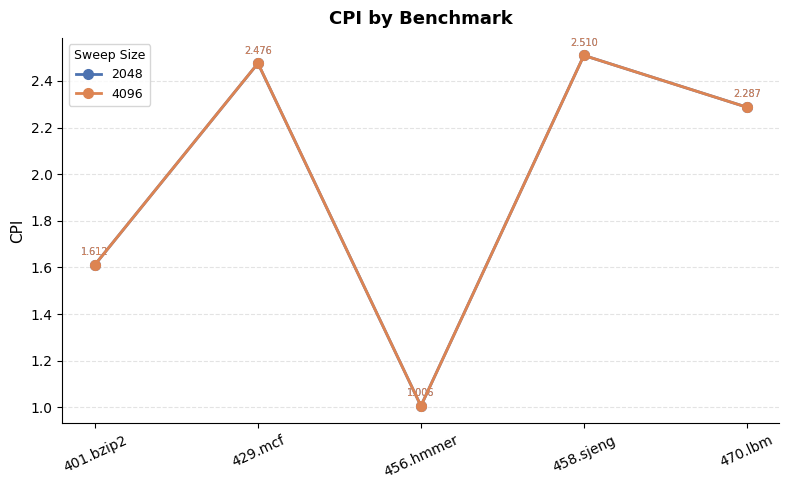

  Saved → globalSweep_cpi_line.png


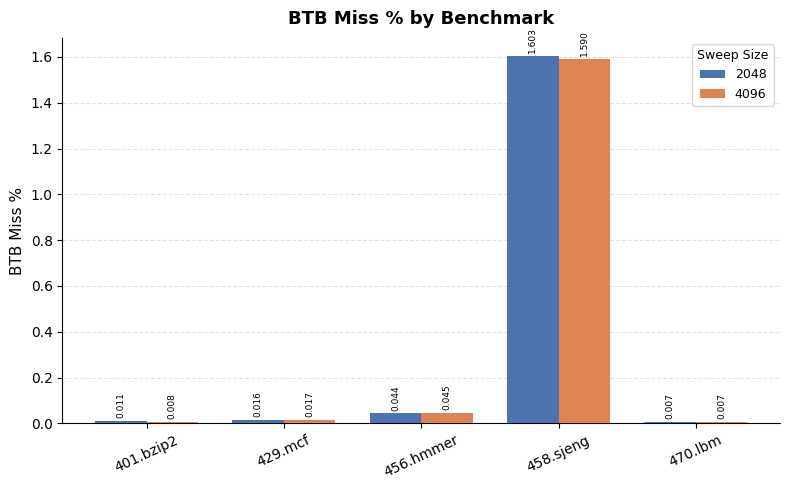

  Saved → globalSweep_btb_miss_pct_bar.png


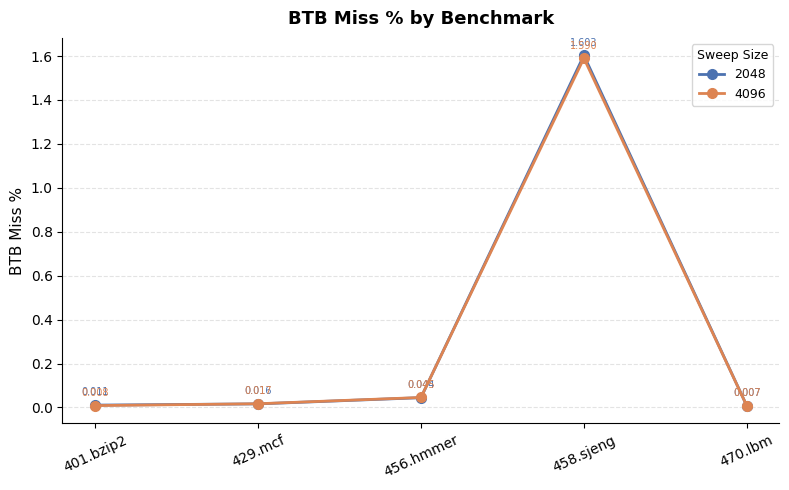

  Saved → globalSweep_btb_miss_pct_line.png


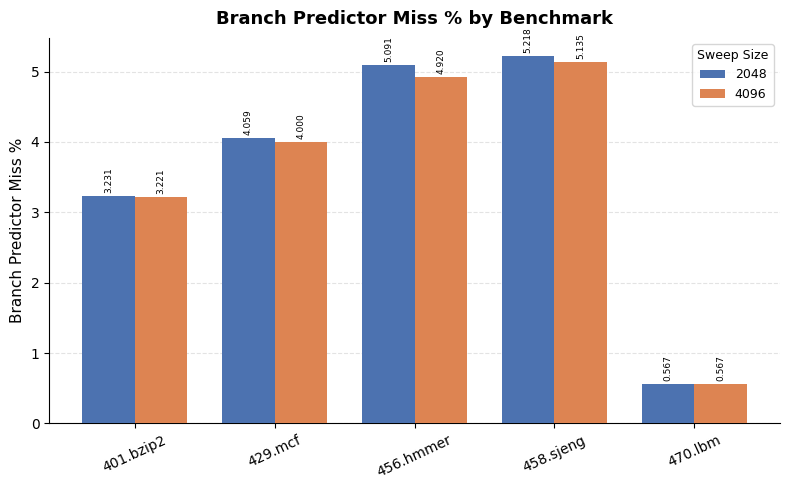

  Saved → globalSweep_branch_pred_miss_pct_bar.png


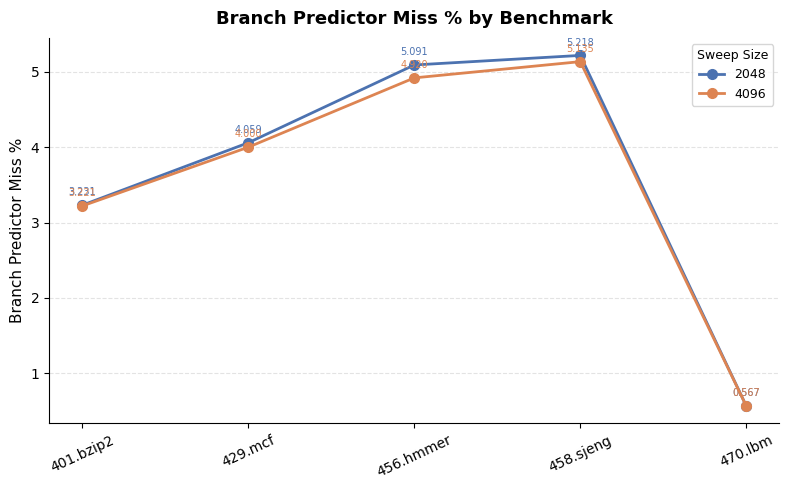

  Saved → globalSweep_branch_pred_miss_pct_line.png
Done.


In [8]:
"""
plot_bench.py
-------------
Reads benchmark sweep data (no header) with columns:
  sweep_size, benchmark, cpi, btb_miss_pct, branch_pred_miss_pct

For each metric, produces:
  - A grouped bar chart  (benchmarks on x-axis, sweep sizes as groups)
  - A line chart         (benchmarks on x-axis, one line per sweep size)

Usage (terminal):
  python plot_bench.py data.txt

Usage (Colab/Jupyter — edit NOTEBOOK_CONFIG below):
  Just run the cell.
"""

import csv
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import defaultdict

# ── COLAB / JUPYTER CONFIG ────────────────────────────────────────────────────
NOTEBOOK_CONFIG = {
    "filepath": "globalPredictroSize_sweep.txt",   # ← change to your file path
    "output":   "globalSweep",          # ← output prefix, or None to use filename
}
# ─────────────────────────────────────────────────────────────────────────────

COLUMNS = ["sweep_size", "benchmark", "cpi", "btb_miss_pct", "branch_pred_miss_pct"]
METRICS = ["cpi", "btb_miss_pct", "branch_pred_miss_pct"]
METRIC_LABELS = {
    "cpi":                 "CPI",
    "btb_miss_pct":        "BTB Miss %",
    "branch_pred_miss_pct":"Branch Predictor Miss %",
}

COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
          "#8172B3", "#937860", "#DA8BC3", "#64B5CD"]


def is_notebook():
    try:
        shell = get_ipython().__class__.__name__  # noqa: F821
        return shell in ("ZMQInteractiveShell", "Shell")
    except NameError:
        return False


def parse_args():
    if is_notebook():
        class Args:
            filepath = NOTEBOOK_CONFIG["filepath"]
            output   = NOTEBOOK_CONFIG["output"]
        return Args()
    import argparse
    p = argparse.ArgumentParser(description="Plot benchmark sweep data.")
    p.add_argument("filepath", help="Path to the CSV data file")
    p.add_argument("--output", default=None, help="Output filename prefix")
    return p.parse_args()


def load_data(filepath):
    """Return a dict: { sweep_size: { benchmark: {metric: value} } }"""
    data = defaultdict(dict)
    with open(filepath, newline="", encoding="utf-8") as f:
        for i, row in enumerate(csv.reader(f), start=1):
            if not row or row[0].startswith("#"):
                continue
            if len(row) != 5:
                sys.exit(f"Line {i}: expected 5 columns, got {len(row)}: {row}")
            sweep  = int(row[0].strip())
            bench  = row[1].strip()
            cpi    = float(row[2])
            btb    = float(row[3])
            branch = float(row[4])
            data[sweep][bench] = {
                "cpi": cpi,
                "btb_miss_pct": btb,
                "branch_pred_miss_pct": branch,
            }
    return data


def style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.legend(title="Sweep Size", fontsize=9, title_fontsize=9)


def make_bar_chart(sweeps, benchmarks, data, metric, base):
    fig, ax = plt.subplots(figsize=(max(8, len(benchmarks) * 1.2), 5))

    n_sweeps = len(sweeps)
    x = np.arange(len(benchmarks))
    width = 0.75 / n_sweeps

    for i, sweep in enumerate(sweeps):
        values = [data[sweep].get(b, {}).get(metric, 0) for b in benchmarks]
        offset = (i - (n_sweeps - 1) / 2) * width
        bars = ax.bar(x + offset, values, width=width,
                      label=str(sweep), color=COLORS[i % len(COLORS)], zorder=3)
        ax.bar_label(bars, fmt="%.3f", fontsize=6.5, padding=2, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    style_ax(ax, f"{METRIC_LABELS[metric]} by Benchmark", METRIC_LABELS[metric])
    fig.tight_layout()
    path = f"{base}_{metric}_bar.png"
    fig.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved → {path}")


def make_line_chart(sweeps, benchmarks, data, metric, base):
    fig, ax = plt.subplots(figsize=(max(8, len(benchmarks) * 1.2), 5))

    x = np.arange(len(benchmarks))
    for i, sweep in enumerate(sweeps):
        values = [data[sweep].get(b, {}).get(metric, 0) for b in benchmarks]
        color  = COLORS[i % len(COLORS)]
        ax.plot(x, values, marker="o", linewidth=2, markersize=7,
                label=str(sweep), color=color, zorder=3)
        for xi, yi in zip(x, values):
            ax.annotate(f"{yi:.3f}", xy=(xi, yi),
                        xytext=(0, 7), textcoords="offset points",
                        ha="center", fontsize=7, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    style_ax(ax, f"{METRIC_LABELS[metric]} by Benchmark", METRIC_LABELS[metric])
    fig.tight_layout()
    path = f"{base}_{metric}_line.png"
    fig.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved → {path}")


def main():
    args     = parse_args()
    filepath = args.filepath

    if not os.path.isfile(filepath):
        sys.exit(f"Error: file not found – {filepath}")

    data       = load_data(filepath)
    sweeps     = sorted(data.keys())
    benchmarks = sorted({b for s in data.values() for b in s})

    print(f"Sweep sizes : {sweeps}")
    print(f"Benchmarks  : {benchmarks}")
    print(f"Metrics     : {METRICS}\n")

    base = args.output or os.path.splitext(filepath)[0]

    for metric in METRICS:
        make_bar_chart(sweeps, benchmarks, data, metric, base)
        make_line_chart(sweeps, benchmarks, data, metric, base)

    print("Done.")


main()